In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import requests
import pandas as pd
import numpy as np
import os
import sys
from datetime import datetime

# ETFs - Goals
Before we start to compare which ETFs are good and which not, we first may need to set common goals on what we expect investing in ETFs. It's cleear that you will not make big money in a short period of time by diversifying your portfolio with ETFs - for those risky and high-reward investments, buy crypto or whatever. For many, ETFs are a long-term investment that you keep around in your portfolio for a long time. There are even some financial experts saying that you should by into an (passive) ETF and forget about it. So generally, investing into ETFs requires *patience*. Not only that, we also have to have the strong, unbreakable *belief* that the ETF we invest in will rise in value on long-term. So let's test, which ETFs are most trusted in rising in value, but also will not take half your life, just to recover from a financial crash.

## Passive ETFs
Now, let's see, which ETFs are worth considering and why

In [2]:
# Define the big ETFs everyone talks about
# Ticker -> Name/Description
popular_etfs = {
    # US Market - S&P 500
    "SPY": "SPDR S&P 500 ETF (US)",
    "VOO": "Vanguard S&P 500 ETF (US)",
    "IVV": "iShares Core S&P 500 ETF (US)",
    # US Market - NASDAQ-100
    "QQQ": "Invesco QQQ Trust (NASDAQ-100, US)",
    # US Market - Total Market
    "VTI": "Vanguard Total Stock Market ETF (US)",
    # US Market - Dow Jones
    "DIA": "SPDR Dow Jones Industrial Average ETF (US)",
    # Global / World
    "VT": "Vanguard Total World Stock ETF (All-World)",
    "URTH": "iShares MSCI World ETF (Developed Markets)",
    "ACWI": "iShares MSCI ACWI ETF (All-Country World)",
    # Emerging Markets
    "EEM": "iShares MSCI Emerging Markets ETF",
    "VWO": "Vanguard FTSE Emerging Markets ETF",
    # Europe
    "VGK": "Vanguard FTSE Europe ETF",
    "IEUR": "iShares Core MSCI Europe ETF",
    # Developed ex-US
    "VEA": "Vanguard FTSE Developed Markets ETF (ex-US)",
    # Bonds (for reference)
    "AGG": "iShares Core US Aggregate Bond ETF",
    "BND": "Vanguard Total Bond Market ETF",
}

print(f"Tracking {len(popular_etfs)} popular ETFs\n")

# Fetch info for all ETFs at once
tickers = yf.Tickers(" ".join(popular_etfs.keys()))

# Collect key metrics into a DataFrame for comparison
etf_data = []
for ticker_symbol, name in popular_etfs.items():
    try:
        etf = tickers.tickers[ticker_symbol]
        info = etf.info
        
        etf_data.append({
            "Ticker": ticker_symbol,
            "Name": name,
            "Current Price": info.get("regularMarketPrice", info.get("previousClose", np.nan)),
            "Market Cap": info.get("marketCap", np.nan),
            "P/E Ratio": info.get("trailingPE", np.nan),
            "Dividend Yield": info.get("dividendYield", np.nan),
            "Expense Ratio": info.get("annualReportExpenseRatio", np.nan),
            "50-Day Avg": info.get("fiftyDayAverage", np.nan),
            "200-Day Avg": info.get("twoHundredDayAverage", np.nan),
            "52W High": info.get("fiftyTwoWeekHigh", np.nan),
            "52W Low": info.get("fiftyTwoWeekLow", np.nan),
            "YTD Return": info.get("ytdReturn", np.nan),
            "3Y Avg Return": info.get("threeYearAverageReturn", np.nan),
            "5Y Avg Return": info.get("fiveYearAverageReturn", np.nan),
            "Beta": info.get("beta", np.nan),
            "AUM": info.get("totalAssets", np.nan),  # Assets Under Management
        })
    except Exception as e:
        print(f"Could not fetch data for {ticker_symbol}: {e}")

# Create DataFrame
df_etfs = pd.DataFrame(etf_data)
df_etfs.set_index("Ticker", inplace=True)

# Format for display
print("=" * 100)
print("POPULAR ETFs - KEY METRICS")
print("=" * 100)
display(df_etfs.style.format({
    "Current Price": "${:.2f}",
    "Market Cap": "${:,.0f}",
    "Dividend Yield": "{:.2%}",
    "Expense Ratio": "{:.4%}",
    "YTD Return": "{:.2%}",
    "3Y Avg Return": "{:.2%}",
    "5Y Avg Return": "{:.2%}",
    "AUM": "${:,.0f}",
    "P/E Ratio": "{:.2f}",
    "Beta": "{:.2f}",
}).background_gradient(cmap="RdYlGn", subset=["5Y Avg Return", "YTD Return"]))

print(f"\nData fetched as of: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Tracking 16 popular ETFs

POPULAR ETFs - KEY METRICS


,Name,Current Price,Market Cap,P/E Ratio,Dividend Yield,Expense Ratio,50-Day Avg,200-Day Avg,52W High,52W Low,YTD Return,3Y Avg Return,5Y Avg Return,Beta,AUM
Ticker,,,,,,,,,,,,,,,
SPY,SPDR S&P 500 ETF (US),$728.99,$nan,26.11,98.00%,nan%,734.351400,690.535700,760.400000,615.040000,1122.98%,20.60%,12.83%,nan,"$783,796,404,224"
VOO,Vanguard S&P 500 ETF (US),$670.26,$nan,26.16,103.00%,nan%,675.263200,635.057500,699.150000,565.380000,1125.20%,20.71%,12.90%,nan,"$1,701,513,003,008"
IVV,iShares Core S&P 500 ETF (US),$730.17,$nan,26.27,106.00%,nan%,737.576000,693.628230,764.000000,617.990000,1125.28%,20.58%,12.83%,nan,"$854,916,988,928"
QQQ,"Invesco QQQ Trust (NASDAQ-100, US)",$706.52,$nan,32.44,38.00%,nan%,702.793400,632.153900,748.650000,544.660000,2035.72%,26.19%,15.81%,nan,"$493,987,528,704"
VTI,Vanguard Total Stock Market ETF (US),$362.22,$nan,25.80,101.00%,nan%,362.064400,340.420800,374.700000,302.600000,1144.11%,20.72%,11.79%,nan,"$2,308,925,030,400"
DIA,SPDR Dow Jones Industrial Average ETF (US),$517.75,$nan,24.57,137.00%,nan%,503.270200,483.316440,526.570000,433.400000,679.85%,17.29%,10.41%,nan,"$44,786,040,832"
VT,Vanguard Total World Stock ETF (All-World),$153.95,$nan,21.98,159.00%,nan%,154.196000,144.614900,159.410000,127.790000,1237.01%,19.85%,10.36%,nan,"$95,332,884,480"
URTH,iShares MSCI World ETF (Developed Markets),$197.36,$nan,23.46,134.00%,nan%,199.871600,188.776550,206.330000,168.230000,1056.98%,19.34%,11.00%,nan,"$8,104,262,144"
ACWI,iShares MSCI ACWI ETF (All-Country World),$154.28,$nan,22.77,138.00%,nan%,154.438000,144.838850,160.030000,127.770000,1214.01%,20.03%,10.63%,nan,"$32,931,053,568"



Data fetched as of: 2026-06-27 20:36


## ETFs — Same Start Date, All Normalized to 100

Now we align all ETFs to start from the **same point in time** (today − MIN_YEARS). This way, every ETF begins at the same date — no matter how long it has existed — and we normalise its price to **100** at that point. This makes the trajectories truly comparable.

Common start date: 2006-06-27  (today − 20 years)
Any ETF without data going back to 2006-06-27 will be excluded.

✅ SPY (S&P 500) — data since 1993-01-29  (5029 trading days)
✅ QQQ (NASDAQ-100) — data since 1999-03-10  (5029 trading days)
✅ DIA (Dow Jones) — data since 1998-01-20  (5029 trading days)
✅ EEM (MSCI Emerging Markets) — data since 2003-04-14  (5029 trading days)
✅ IWM (Russell 2000 (Small Cap)) — data since 2000-05-26  (5029 trading days)
✅ MDY (S&P MidCap 400) — data since 1995-05-04  (5029 trading days)
✅ XLE (Energy Select Sector) — data since 1998-12-22  (5029 trading days)
✅ XLF (Financial Select Sector) — data since 1998-12-22  (5029 trading days)
✅ GLD (Gold Trust) — data since 2004-11-18  (5029 trading days)
✅ TLT (20+ Year Treasury Bonds) — data since 2002-07-30  (5029 trading days)
10 ETF(s) qualify — all start from 2006-06-27.


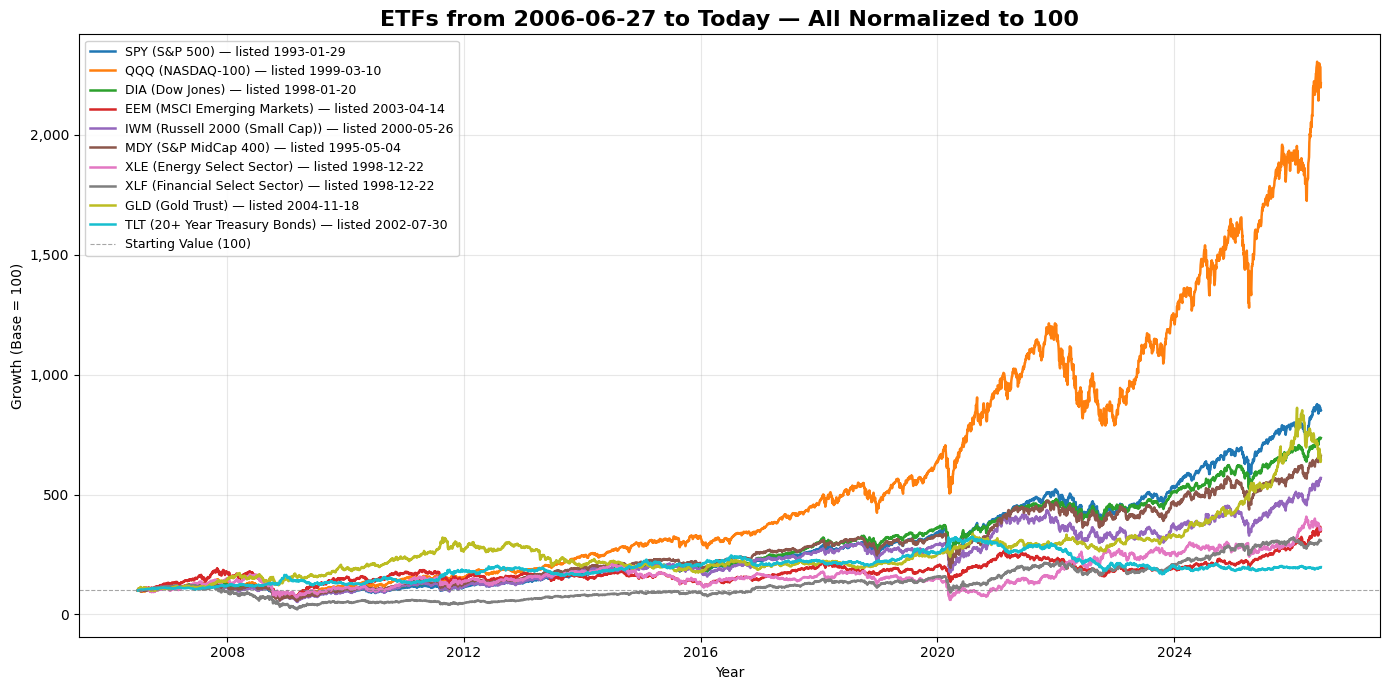


SUMMARY: Growth Since the Common Start Date


,Listed Since,Trading Days,Start Price,Current Price,Total Growth,CAGR
ETF,,,,,,
SPY,1993-01-29,5029,$86.38,$734.30,750.1%,11.32%
QQQ,1999-03-10,5029,$32.33,$716.38,2115.9%,16.80%
DIA,1998-01-20,5029,$70.55,$519.26,636.0%,10.52%
EEM,2003-04-14,5029,$19.48,$67.96,248.9%,6.46%
IWM,2000-05-26,5029,$52.51,$298.91,469.2%,9.11%
MDY,1995-05-04,5029,$105.51,$697.38,561.0%,9.93%
XLE,1998-12-22,5029,$15.22,$54.09,255.3%,6.56%
XLF,1998-12-22,5029,$17.39,$53.45,207.4%,5.79%
GLD,2004-11-18,5029,$57.54,$369.46,542.1%,9.77%


In [ ]:
# ETFs to check — focus on the most well-known ones with potentially long history
candidates = {
    "SPY": "S&P 500",
    "QQQ": "NASDAQ-100",
    "DIA": "Dow Jones",
    "EEM": "MSCI Emerging Markets",
    "IWM": "Russell 2000 (Small Cap)",
    "MDY": "S&P MidCap 400",
    "XLE": "Energy Select Sector",
    "XLF": "Financial Select Sector",
    "GLD": "Gold Trust",
    "TLT": "20+ Year Treasury Bonds",
}

MIN_YEARS = 20

# Compute the common start date: today minus MIN_YEARS
today = datetime.today()
common_start = today.replace(year=today.year - MIN_YEARS)
print(f"Common start date: {common_start.strftime('%Y-%m-%d')}  (today − {MIN_YEARS} years)")
print(f"Any ETF without data going back to {common_start.strftime('%Y-%m-%d')} will be excluded.\n")

# Download all historical data (adjusted close)
all_data = yf.download(
    list(candidates.keys()),
    period="max",
    auto_adjust=True,
    progress=False,
)

# Extract 'Close' prices
if len(candidates) > 1:
    closes = all_data["Close"]
else:
    closes = all_data[["Close"]]

# Filter: keep only ETFs that existed before the common start date
valid = {}
for ticker, name in candidates.items():
    series = closes[ticker].dropna()
    first_date = series.index[0]
    
    if first_date <= common_start:
        # Slice from common_start onwards
        sliced = series[series.index >= common_start]
        valid[ticker] = {"name": name, "series": sliced, "start": first_date.strftime("%Y-%m-%d")}
        print(f"✅ {ticker} ({name}) — data since {first_date.strftime('%Y-%m-%d')}  ({len(sliced)} trading days)")
    else:
        print(f"❌ {ticker} ({name}) — only since {first_date.strftime('%Y-%m-%d')} (too young)")

if not valid:
    print(f"No ETF existed before {common_start.strftime('%Y-%m-%d')}! Try a lower MIN_YEARS.")
else:
    print(f"{len(valid)} ETF(s) qualify — all start from {common_start.strftime('%Y-%m-%d')}.")

    # ---- Normalize & Plot ----
    fig, ax = plt.subplots(figsize=(14, 7))

    colors = plt.cm.tab10(np.linspace(0, 1, len(valid)))

    for (ticker, data), color in zip(valid.items(), colors):
        series = data["series"]
        # Normalise: first price in the common window = 100
        normalized = series / series.iloc[0] * 100
        label = f"{ticker} ({data['name']}) — listed {data['start']}"
        ax.plot(normalized.index, normalized, label=label, color=color, linewidth=1.8)

    # Baseline at 100
    ax.axhline(y=100, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="Starting Value (100)")

    ax.set_title(f"ETFs from {common_start.strftime('%Y-%m-%d')} to Today — All Normalized to 100", fontsize=16, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Growth (Base = 100)")
    ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3, which="both")
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    plt.tight_layout()
    plt.show()

    # ---- Summary table ----
    print("\n" + "=" * 90)
    print("SUMMARY: Growth Since the Common Start Date")
    print("=" * 90)
    summary_rows = []
    for ticker, data in valid.items():
        s = data["series"]
        years = len(s) / 252
        summary_rows.append({
            "ETF": ticker,
            "Listed Since": data["start"],
            "Trading Days": len(s),
            "Start Price": f"${s.iloc[0]:.2f}",
            "Current Price": f"${s.iloc[-1]:.2f}",
            "Total Growth": f"{(s.iloc[-1] / s.iloc[0] - 1) * 100:.1f}%",
            "CAGR": f"{((s.iloc[-1] / s.iloc[0]) ** (252 / len(s)) - 1) * 100:.2f}%",
        })
    display(pd.DataFrame(summary_rows).set_index("ETF"))